# Bước 08: Giải Thích Mô Hình Chi Tiết Với SHAP (Explainable AI - XAI)
Dự án: Tốt nghiệp - Energy Forecasting - Nhóm thực hiện: The Outliers
Nguồn tham chiếu: `srcs/05_machine_learning/Forcasting_v3/12_explainable_ai.py`

**MỤC TIÊU BƯỚC ĐÁNH GIÁ VÀ GIẢI THÍCH MÔ HÌNH (XAI):**
- Sử dụng **SHAP (SHapley Additive exPlanations)** để giải thích độ đóng góp của từng đặc trưng (Feature Importance).
- Phân tích mối quan hệ phi tuyến giữa các biến thời tiết (bức xạ ghi, poa, dhi, nhiệt độ) và sản lượng phát điện.
- Hỗ trợ **cả 2 phương án đặc trưng (`full` có lag_1 vs `no_lag1` không lag_1)** để so sánh sự thay đổi tầm quan trọng của các nhóm tính năng.

## Bước 2. Import thư viện SHAP và khai báo tham số (FEATURE_SET_NAME)

In [2]:
# ── Gioi han thread: may i5-12450HX co 8 core / 12 thread (4 P-core + 4 E-core).
# Dung het 12 thread lam cac thread tranh nhau va CHAM HON. Dat 6 de bam P-core,
# con lai de cho Jupyter va he dieu hanh. Phai set TRUOC khi numpy nap moi co tac dung.
import os

for _bien in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
              'NUMEXPR_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_bien, '6')

import gc
import json
import os
import pickle
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import pyarrow.parquet as pq
import seaborn as sns
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# ── Tham số cấu hình ──
VERSION = 'v3'
SITE_COL = 'site_id'
TIMESTAMP_COL = 'timestamp'
TARGET_COL = 'energy_generated_kwh'

# Notebook 06_1 ghi vao 06_train/huber/h1 nen feature set de trong
FEATURE_SET_NAME = ""
LOSS_NAME = "huber"

SELECTED_DIR = '../../data/model/v3/05_selected'
TRAIN_BASE_DIR = '../../data/model/v3/06_train'
TEST_FINAL_DIR = '../../data/model/v3/07_final_test'
OUTPUT_DIR = '../../data/model/v3/08_explain'

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Đã import thư viện SHAP và khai báo tham số.")
print(f"- Loss name        : {LOSS_NAME}")
print(f"- Feature set name : '{FEATURE_SET_NAME}'")
print(f"- Output directory : {OUTPUT_DIR}")


Đã import thư viện SHAP và khai báo tham số.
- Loss name        : huber
- Feature set name : ''
- Output directory : ../../data/model/v3/08_explain


## Bước 3. Nạp mô hình huấn luyện và dữ liệu tập Test

In [3]:
folder_name = f"{LOSS_NAME}_{FEATURE_SET_NAME}" if FEATURE_SET_NAME else LOSS_NAME
model_path = f'{TRAIN_BASE_DIR}/{folder_name}/h1/model.pkl'

if not os.path.exists(model_path):
    model_path = f'{TRAIN_BASE_DIR}/{folder_name}/model.pkl'

if not os.path.exists(model_path):
    # Fallback mô hình vô địch từ 07
    best_json = f'{TEST_FINAL_DIR}/best_loss.json'
    if os.path.exists(best_json):
        with open(best_json) as f:
            b_data = json.load(f)
            folder_name = b_data.get('h1', {}).get('folder_name', 'huber')
            model_path = f'{TRAIN_BASE_DIR}/{folder_name}/h1/model.pkl'

print(f"Đang nạp mô hình từ: {model_path}")
with open(model_path, 'rb') as f:
    model = pickle.load(f)

# Đọc danh sách đặc trưng đã dùng
config_path = model_path.replace('model.pkl', 'model_config.json')
with open(config_path, 'r', encoding='utf-8') as f:
    m_config = json.load(f)

features = m_config['features']
feature_medians = pd.Series(m_config['feature_medians'], dtype=float)

# Nạp tập Test.
# Notebook 06_1 xuat san ma tran test kem dac trung moi (goc mat troi, buc xa downscale,
# quy mo tram). Neu co file do thi dung, vi 05_selected khong chua cac cot nay.
# Ma tran test do NOTEBOOK 07 ghi ra, khong phai notebook 06.
# Tap test chi duoc mo DUY NHAT 1 lan o notebook 07 (sau khi mo hinh vo dich da chon
# xong bang so lieu validation). Notebook nay dung lai snapshot do - khong tu mo test.
# Truoc day dong nay tro vao 06_train/<loss>/h1/X_test_h1.parquet, nhung tu khi khoa
# tap test thi notebook 06 khong con ghi file do -> se doc phai file cu.
x_test_path = f'{TEST_FINAL_DIR}/h1/X_test_h1.parquet'

if os.path.exists(x_test_path):
    print(f"Dùng ma trận test có sẵn từ notebook 06: {x_test_path}")
    test_df = pd.read_parquet(x_test_path)
else:
    test_path = f'{SELECTED_DIR}/{VERSION}_test_selected.parquet'
    print(f"Không thấy ma trận có sẵn, đọc từ: {test_path}")
    test_df = pd.read_parquet(test_path)
    if 'exclude_from_training' in test_df.columns:
        test_df = test_df[test_df['exclude_from_training'] == False]
    if 'has_complete_history_features' in test_df.columns:
        test_df = test_df[test_df['has_complete_history_features'] == True]

test_df = test_df.reset_index(drop=True)
feat_cols = [c for c in features if c in test_df.columns]
num_cols = [c for c in feat_cols if pd.api.types.is_numeric_dtype(test_df[c])]
feat_cols = num_cols

_thieu = [c for c in features if c not in feat_cols]
if _thieu:
    print(f"[CANH BAO] Thieu {len(_thieu)} dac trung trong tap test: {_thieu[:8]}")

X_test_full = test_df[feat_cols].fillna(feature_medians).astype(float)
print(f"Đã nạp tập Test gồm {len(X_test_full):,} dòng và {len(feat_cols)} đặc trưng.")


Đang nạp mô hình từ: ../../data/model/v3/06_train/huber/h1/model.pkl
Dùng ma trận test có sẵn từ notebook 06: ../../data/model/v3/07_final_test/h1/X_test_h1.parquet
Đã nạp tập Test gồm 486,120 dòng và 54 đặc trưng.


## Bước 4. Tính toán giá trị SHAP (TreeExplainer)

In [4]:
# Lấy mẫu 2,000 dòng đại diện để tính SHAP TreeExplainer nhanh chóng
np.random.seed(42)
sample_idx = np.random.choice(len(X_test_full), size=min(2000, len(X_test_full)), replace=False)
X_sample = X_test_full.iloc[sample_idx].copy()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# Chuyển thành DataFrame
df_shap = pd.DataFrame(shap_values, columns=feat_cols, index=X_sample.index)
mean_abs_shap = np.abs(shap_values).mean(axis=0)

df_importance = pd.DataFrame({
    'feature': feat_cols,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

print("TOP 10 ĐẶC TRƯNG CÓ TẦM QUAN TRỌNG TỔNG THỂ LỚN NHẤT (SHAP):")
display(df_importance.head(10))

# Ghi kết quả SHAP ra ổ đĩa
suffix = f"_{FEATURE_SET_NAME}" if FEATURE_SET_NAME else ""
df_importance.to_csv(f'{OUTPUT_DIR}/shap_importance{suffix}.csv', index=False)
df_importance.to_csv(f'{OUTPUT_DIR}/shap_importance.csv', index=False)

sample_meta = test_df.iloc[sample_idx][[SITE_COL, TIMESTAMP_COL]].copy()
df_shap_full = pd.concat([sample_meta, df_shap], axis=1)
df_shap_full.to_parquet(f'{OUTPUT_DIR}/shap_values{suffix}.parquet', index=False)
df_shap_full.to_parquet(f'{OUTPUT_DIR}/shap_values.parquet', index=False)

print(f"Đã lưu kết quả SHAP ({FEATURE_SET_NAME}) vào thư mục: {OUTPUT_DIR}")

TOP 10 ĐẶC TRƯNG CÓ TẦM QUAN TRỌNG TỔNG THỂ LỚN NHẤT (SHAP):


,feature,mean_abs_shap
9,minute_of_day,0.091205
2,rolling_min_4,0.065967
21,direct_normal_irradiance,0.060132
4,ky_vong,0.059929
16,hour_cos,0.055546
0,rolling_max_4,0.053977
1,rolling_mean_4,0.051288
32,tran_cong_suat,0.033869
10,rolling_std_4,0.028778
13,rad_x_sinelev,0.024257


Đã lưu kết quả SHAP () vào thư mục: ../../data/model/v3/08_explain


## Bước 5. Trực quan hóa Global SHAP Summary / Beeswarm Plot

--- BIỂU ĐỒ GLOBAL SHAP BEESWARM PLOT ---


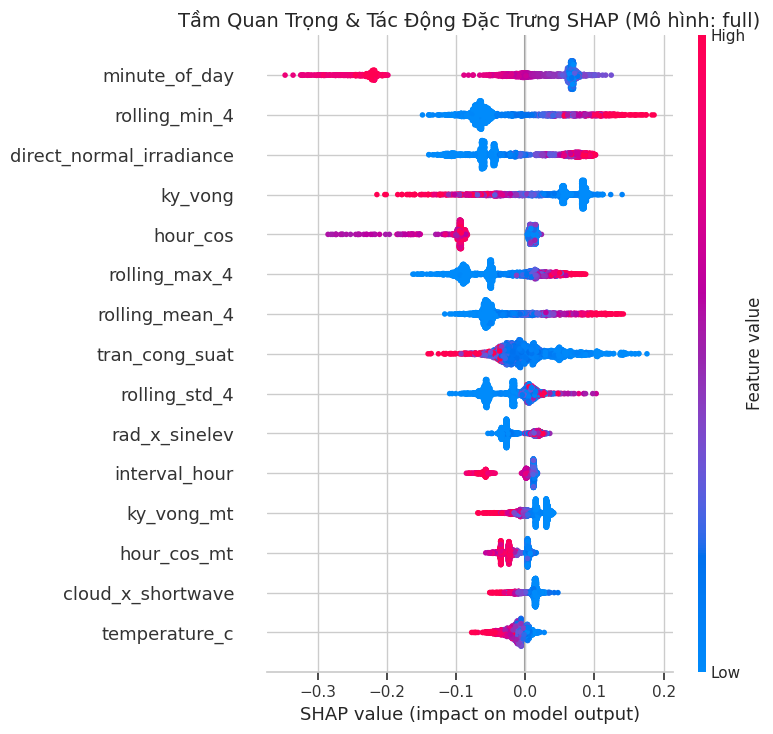

In [5]:
print("--- BIỂU ĐỒ GLOBAL SHAP BEESWARM PLOT ---")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.title(f"Tầm Quan Trọng & Tác Động Đặc Trưng SHAP (Mô hình: {FEATURE_SET_NAME if FEATURE_SET_NAME else 'full'})", fontsize=14)
plt.tight_layout()
plt.show()

## Bước 6. Phân tích mối quan hệ phụ thuộc (SHAP Dependence Plots)

--- BIỂU ĐỒ SHAP DEPENDENCE PLOTS CHO 4 ĐẶC TRƯNG HÀNG ĐẦU ---


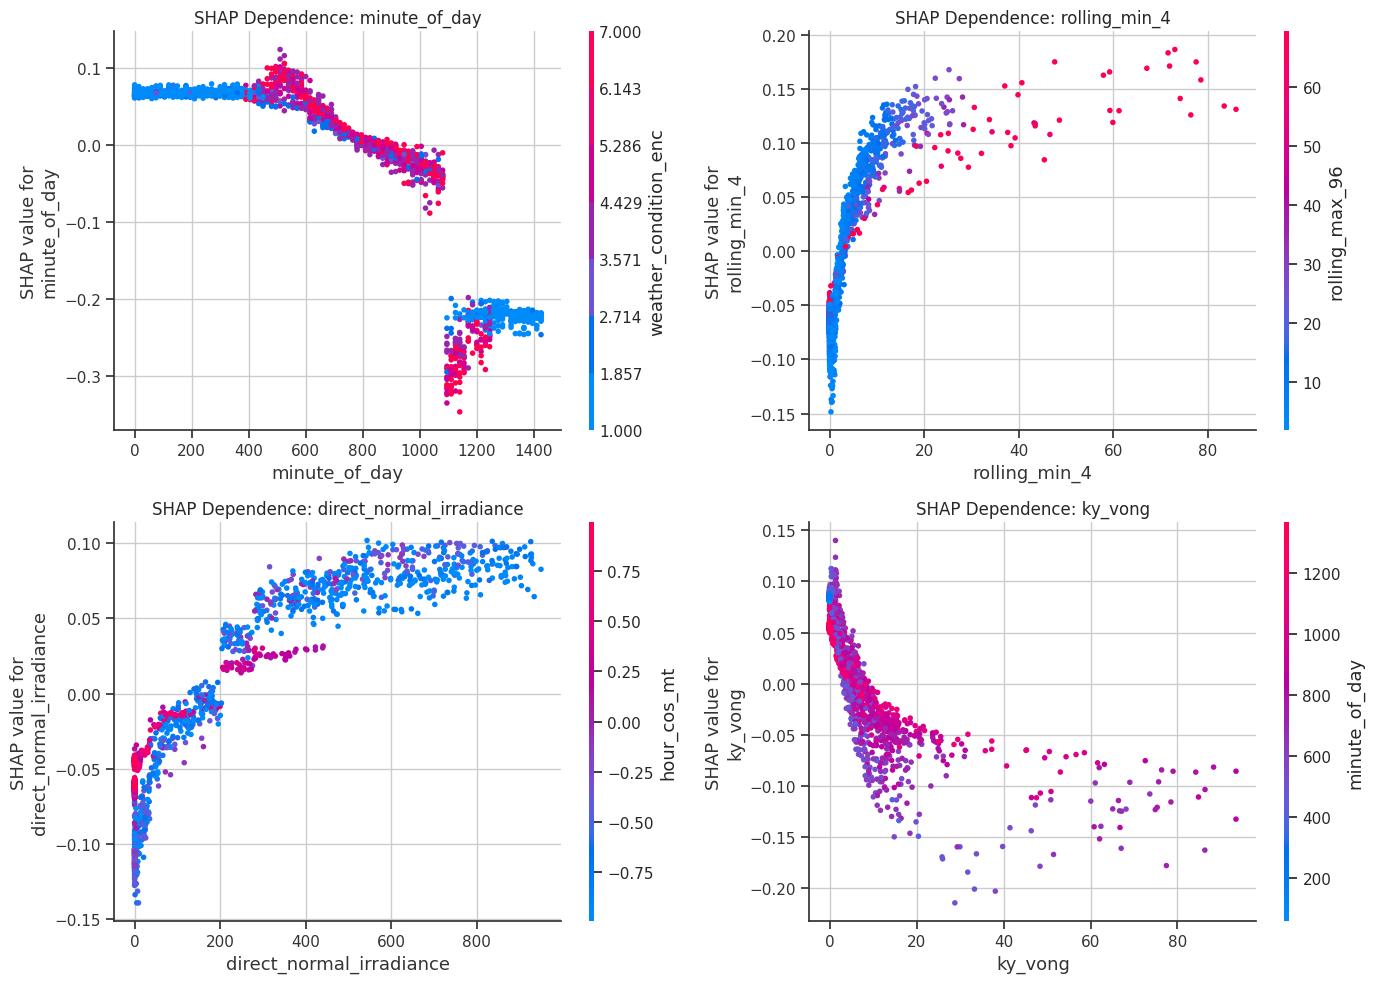

In [6]:
top_features = df_importance['feature'].head(4).tolist()
print("--- BIỂU ĐỒ SHAP DEPENDENCE PLOTS CHO 4 ĐẶC TRƯNG HÀNG ĐẦU ---")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    shap.dependence_plot(feat, shap_values, X_sample, ax=axes[i], show=False)
    axes[i].set_title(f"SHAP Dependence: {feat}")

plt.tight_layout()
plt.show()

## Bước 7. Giải thích mô hình cục bộ (Local Waterfall Plot)

--- BIỂU ĐỒ SHAP WATERFALL PLOT CHO CÁC MẪU ĐẠI DIỆN ---


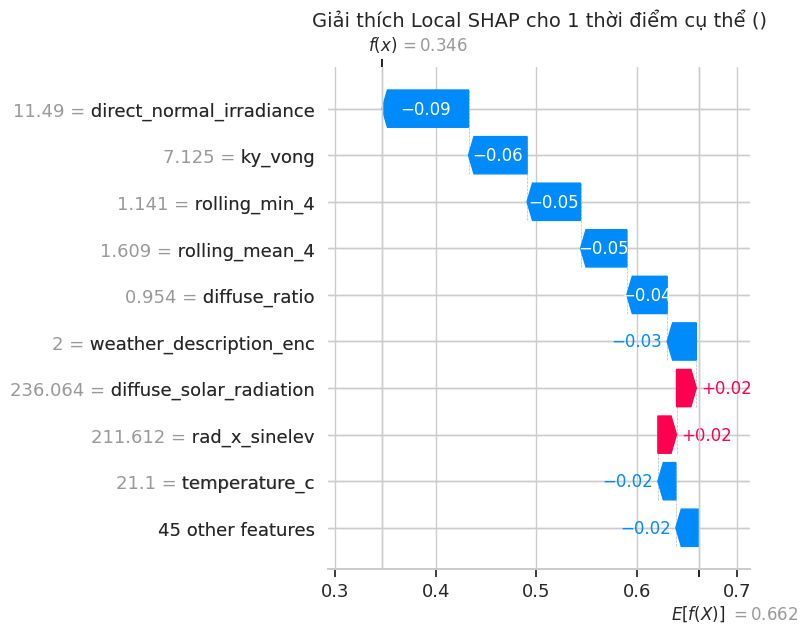

In [7]:
print("--- BIỂU ĐỒ SHAP WATERFALL PLOT CHO CÁC MẪU ĐẠI DIỆN ---")
# Chọn mẫu có sản lượng cao nhất và mẫu có sai số lớn nhất
sample_high_idx = 0
ex = shap.Explanation(
    values=shap_values[sample_high_idx],
    base_values=explainer.expected_value,
    data=X_sample.iloc[sample_high_idx].values,
    feature_names=feat_cols
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(ex, max_display=10, show=False)
plt.title(f"Giải thích Local SHAP cho 1 thời điểm cụ thể ({FEATURE_SET_NAME})", fontsize=14)
plt.tight_layout()
plt.show()

## Bước 8. Biểu đồ Plotly Tương tác Dropdown cho 42 Trạm

In [8]:
print("Đang chuẩn bị biểu đồ Plotly tương tác cho 42 trạm quang điện...")

audit_path = f'{TEST_FINAL_DIR}/prediction_audit.parquet'
if os.path.exists(audit_path):
    audit_df = pd.read_parquet(audit_path)
else:
    audit_df = test_df[[SITE_COL, TIMESTAMP_COL, TARGET_COL]].copy()
    audit_df = audit_df.rename(columns={TARGET_COL: 'y_true'})
    audit_df['y_pred'] = model.predict(X_test_full)

y_true_col = 'y_true_h1' if 'y_true_h1' in audit_df.columns else ('y_true' if 'y_true' in audit_df.columns else TARGET_COL)
y_pred_col = 'y_pred_h1' if 'y_pred_h1' in audit_df.columns else 'y_pred'

sites = sorted(audit_df[SITE_COL].unique())

fig = go.Figure()

for i, s_id in enumerate(sites):
    site_data = audit_df[audit_df[SITE_COL] == s_id].sort_values(TIMESTAMP_COL).head(300)
    visible = (i == 0)

    fig.add_trace(go.Scatter(
        x=site_data[TIMESTAMP_COL], y=site_data[y_true_col],
        mode='lines', name='Thực tế (' + str(s_id) + ')',
        visible=visible, line=dict(color='blue')
    ))
    fig.add_trace(go.Scatter(
        x=site_data[TIMESTAMP_COL], y=site_data[y_pred_col],
        mode='lines', name='Dự báo (' + str(s_id) + ')',
        visible=visible, line=dict(color='orange', dash='dash')
    ))

buttons = []
for i, s_id in enumerate(sites):
    visible_list = [False] * (len(sites) * 2)
    visible_list[i * 2] = True
    visible_list[i * 2 + 1] = True

    buttons.append(dict(
        label=str(s_id),
        method='update',
        args=[{'visible': visible_list}, {'title': 'Dự Báo vs Thực Tế tại Trạm: ' + str(s_id)}]
    ))

fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons, x=0.15, y=1.15, xanchor='left', yanchor='top')],
    title='Dự Báo vs Thực Tế tại Trạm: ' + str(sites[0]),
    xaxis_title='Thời gian',
    yaxis_title='Sản lượng (kWh)',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()

Đang chuẩn bị biểu đồ Plotly tương tác cho 42 trạm quang điện...
